# Latent Variable Models (Logistic Regression)

### Foundations of Machine Learning

**Q1.** Please answer the following questions in your own words:

1. Why do we use general linear models/latent variable models/activation functions in analysis? What advantage do they have over linear models?
2. Explain why binary and categorical cross entropy are effective loss functions for fitting logistic regression models.
3. True or false, and explain: Logistic regression is a linear model.
4. True or false, and explain: Logistic regression cannot be used for classification.
5. Does the coefficient in a logistic regression represent the change in the predicted value for a 1 unit change in the feature/covariate/explanatory variable?
6. True or false, and explain: Feature engineering is unnecessary for logistic regression, because it is a nonlinear model.
7. True or false, and explain: Logistic regression is an improvement over the usual linear model (ordinary least squares), and you should always use logistic regression instead.

1. Linear models are too simple because they assume everything follows a straight line and they can give any value, even ones that don’t make sense like probabilities below 0 or above 1. Models like GLMs and activation functions help fix this by letting the relationship bend and by keeping outputs in the right range, so they fit real data better.

2. Cross entropy works well for logistic regression because the model is trying to predict probabilities. This loss function checks how far off those probabilities are from the true answers and punishes the model a lot when it is very confident and wrong, which helps it learn better.

3. Logistic regression is a linear model in how it uses the inputs and weights, but the final output goes through a curve, so the result is not a straight line. So it is partly linear and partly not.

4. The statement that logistic regression cannot be used for classification is false because that is exactly what it is made for. It gives a probability, and then you use a cutoff to decide the class.

5. The coefficient in logistic regression does not directly tell you how much the prediction changes. It tells you how much the log-odds change, which is harder to interpret, and the actual change in probability is not a straight line.

6. The statement that feature engineering is unnecessary is false because the model still treats inputs in a linear way. You still need to add things like squared terms or interactions if you want to capture more complex patterns.

7. The statement that logistic regression is always better than regular linear regression is false because they are used for different things. Logistic regression is for classification, and linear regression is for predicting numbers, so one is not always better than the other.

**Q2.** This is a question about student dropout probability.

The relevant data are in `data.csv` and the file is semicolon-separated.

The relevant variables are:
- `Debtor` - `1` if the student has outstanding debt and `0` otherwise
- `Tuition fees up to date` - `1` if tuition is up to date and `0` otherwise
- `Scholarship holder` - `1` if the student has a scholarship and `0` otherwise
- `Age at enrollment` - student's age when entering the program
- `Curricular units 1st sem (approved)` - number of first-semester courses passed
- `Target` - `Dropout`, `Graduate`, or `Enrolled`

1. Load the data, `data.csv`. Be sure to read it with the correct delimiter. Filter on columns to the variables we'll actually use. Document how you handle any missing values. For parts 2-5, create a binary target where `Dropout` corresponds to dropout and `Graduate` or `Enrolled` corresponds to not dropout.

2. Run a logistic regression of dropout status on `Debtor`, `Tuition fees up to date`, `Scholarship holder`, and `Age at enrollment`. Which variables predict a higher dropout probability, and which predict a lower dropout probability? Does being up to date on tuition seem to reduce dropout risk?

3. Use `.predict_proba` and compute expected dropout probabilities. Make a scatter plot of your predicted dropout probability against `Age at enrollment`, hued by `Tuition fees up to date`. For what ages does being up to date on tuition seem to reduce dropout probability the most? On average, by how much does being up to date on tuition change the predicted probability of dropout?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted dropout probabilities with a linear model with the same variables, and predict dropout probabilities. Make a histogram of predicted probabilities for both logistic regression and the linear model. Compare their performance.

5. Based on your above work, which students are the most at-risk of dropping out? What kinds of interventions can you imagine that would help at-risk students stay enrolled?

6. Run a multinomial logistic regression of `Target` on `Debtor`, `Tuition fees up to date`, and `Curricular units 1st sem (approved)`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?


In [1]:
! git clone https://github.com/smerashanmugan/scratchpad
%run ./scratchpad/get_data.py

Cloning into 'scratchpad'...
remote: Enumerating objects: 43, done.
remote: Counting objects: 100% (17/17), done.
remote: Compressing objects: 100% (11/11), done.
remote: Total 43 (delta 13), reused 6 (delta 6), pack-reused 26 (from 2)
Receiving objects: 100% (43/43), 122.17 KiB | 4.70 MiB/s, done.
Resolving deltas: 100% (14/14), done.
Download complete
Extracting data files...
Data extracted


In [5]:
import pandas as pd

df = pd.read_csv('./data/data.csv', sep=';')
df.columns = df.columns.str.strip().str.replace('\t', '', regex=True)

df = df[[
    "Debtor",
    "Tuition fees up to date",
    "Scholarship holder",
    "Age at enrollment",
    "Curricular units 1st sem (approved)",
    "Target"
]]
df = df.dropna()
df["dropout"] = (df["Target"] == "Dropout").astype(int)


In [7]:
from sklearn.linear_model import LogisticRegression
import pandas as pd

X = df[[
    "Debtor",
    "Tuition fees up to date",
    "Scholarship holder",
    "Age at enrollment"
]]

y = df["dropout"]
model = LogisticRegression(max_iter=1000)
model.fit(X, y)
coeffs = pd.Series(model.coef_[0], index=X.columns)
print(coeffs)

Debtor                     0.530625
Tuition fees up to date   -2.556542
Scholarship holder        -1.227442
Age at enrollment          0.049925
dtype: float64


2. Variables with positive coefficients increase dropout probability, and variables with negative coefficients decrease it. Debtor and Age at enrollment have positive coefficients, so they predict a higher chance of dropping out. Tuition fees up to date and Scholarship holder have negative coefficients, so they predict a lower chance of dropping out. Being up to date on tuition clearly reduces dropout risk since it has a large negative coefficient.

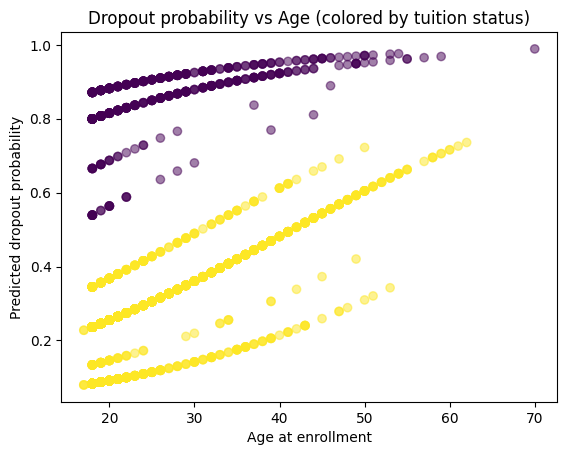

Average difference: 0.6125849339840048


In [9]:
import matplotlib.pyplot as plt
import numpy as np

df["pred_prob"] = model.predict_proba(X)[:, 1]
plt.scatter(
    df["Age at enrollment"],
    df["pred_prob"],
    c=df["Tuition fees up to date"],
    alpha=0.5
)
plt.xlabel("Age at enrollment")
plt.ylabel("Predicted dropout probability")
plt.title("Dropout probability vs Age (colored by tuition status)")
plt.show()
avg_not_up_to_date = df[df["Tuition fees up to date"] == 0]["pred_prob"].mean()
avg_up_to_date = df[df["Tuition fees up to date"] == 1]["pred_prob"].mean()

print("Average difference:", avg_not_up_to_date - avg_up_to_date)

3. Being up to date on tuition reduces dropout probability the most at older ages, since the gap between the two groups gets larger as age increases. On average, being up to date on tuition lowers the predicted probability of dropout by about 0.61, meaning around a 61 percentage point decrease.

In [10]:
from sklearn.metrics import confusion_matrix, accuracy_score

y_pred = model.predict(X)
cm = confusion_matrix(y, y_pred)
print(cm)
acc = accuracy_score(y, y_pred)
print("Accuracy:", acc)

[[2841  162]
 [ 891  530]]
Accuracy: 0.7619801084990958


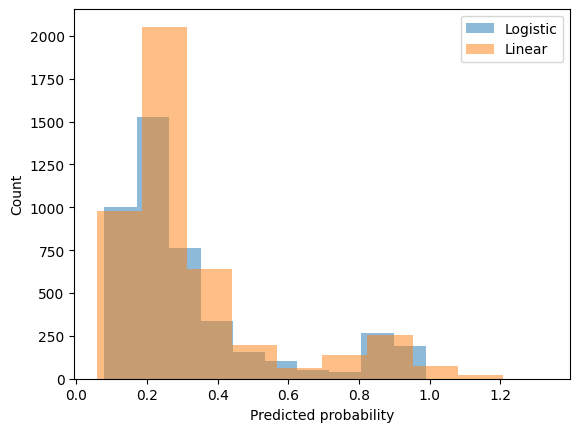

In [11]:
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

lin_model = LinearRegression()
lin_model.fit(X, y)

lin_probs = lin_model.predict(X)
log_probs = model.predict_proba(X)[:, 1]

plt.hist(log_probs, alpha=0.5, label="Logistic")
plt.hist(lin_probs, alpha=0.5, label="Linear")
plt.legend()
plt.xlabel("Predicted probability")
plt.ylabel("Count")
plt.show()

5. The logistic regression model performs better because its predicted probabilities stay between 0 and 1, which makes sense for probabilities. The linear model produces some values above 1, which are not valid probabilities. The logistic model also gives a more realistic distribution of predictions, while the linear model is less reliable for this type of problem.

6. Students most at risk are those who are debtors, not up to date on tuition, not scholarship holders, and older at enrollment, since all of those are linked to higher predicted dropout probability.
To help these students, schools could focus on financial support like payment plans or emergency aid, since money seems to be a big factor. They could also provide academic support early on, especially for students who might be struggling, and offer advising or check-ins to keep them engaged and on track.

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
import pandas as pd

X_multi = df[[
    "Debtor",
    "Tuition fees up to date",
    "Curricular units 1st sem (approved)"
]]
y_multi = df["Target"]

multi_model = LogisticRegression(multi_class="multinomial", max_iter=1000)
multi_model.fit(X_multi, y_multi)
multi_preds = multi_model.predict(X_multi)
cm_multi = confusion_matrix(y_multi, multi_preds)
print(cm_multi)
multi_probs = multi_model.predict_proba(X_multi)
print(multi_probs[:5])
print(multi_model.classes_)

[[1054    0  367]
 [ 280    0  514]
 [ 146    0 2063]]
[[0.68054695 0.21046429 0.10898876]
 [0.69541412 0.1460432  0.15854268]
 [0.95298821 0.04119918 0.00581261]
 [0.11780804 0.1769832  0.70520876]
 [0.18422683 0.21266883 0.60310434]]
['Dropout' 'Enrolled' 'Graduate']


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


7. The confusion matrix shows that the model is mostly predicting dropout and graduate, but it is not predicting enrolled at all. The entire middle column is zero, which means none of the predictions were classified as enrolled. This suggests the model is not doing a good job separating enrolled from the other two groups and is leaning toward the more common outcomes.
The predicted probabilities still include all three classes. Each row has three values for dropout, enrolled, and graduate, so the model is still assigning some probability to enrolled even though it never picks it as the final prediction. So the hard classification does not predict every class, but the predicted probabilities do include every class.

**Q3.** This is a question about 10-year survival rate for cirrhosis of the liver.

The relevant data are:
- `Bilirubin` - A liver byproduct produced when red blood cells break down
- `Edema` - Swelling in limbs; `N` for none, `S` for edema resolvable with diuretics, `Y` for edema despite dirutics
- `Drug` - D-penicillamine, or placebo
- `Stage` - current state of disease, from 1 to 4
- `Status` - `C` or `CL` corresponds to alive, and `D` corresponds to dead

1. Load the data, `cirrhosis.csv`. Filter on columns to the variables we'll actually use. Document how you handle any missing values.

2. Run a logistic regression of `Status` on `Edema`, `Drug`, and `Bilirubin`. Does the drug improve survival probability? Does higher or lower bilirubin predict a higher or lower survival rate? How does survival rate vary with edema?

3. Use `.predict_proba` and compute expected surivival probabilities. Make a scatter plot of your predicted survival probability against `Bilirubin`, hued by `Drug`. For what values of `Bilirubin` does the drug seem to increase patient survival rate? On average, by how much do patients who take the drug increase their probability of survival?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted survival probabilities with a linear model with the same variables, and predict survival probabilties. Make a histogram of predictive probabilties for both logistic regression and the linear model. Compare their performance.

6. Run a logistic regression of `Stage` on `Edema` and `Bilirubin`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?

In [13]:
import pandas as pd

df = pd.read_csv('./data/cirrhosis.csv')
df = df[["Bilirubin", "Edema", "Drug", "Stage", "Status"]]
df = df.dropna()
df["survival"] = df["Status"].isin(["C", "CL"]).astype(int)
df["Edema"] = df["Edema"].map({"N": 0, "S": 1, "Y": 2})
df["Drug"] = df["Drug"].map({"Placebo": 0, "D-penicillamine": 1})

In [14]:
from sklearn.linear_model import LogisticRegression

X = df[["Edema", "Drug", "Bilirubin"]]
y = df["survival"]
model = LogisticRegression(max_iter=1000)
model.fit(X, y)
coeffs = pd.Series(model.coef_[0], index=X.columns)
print(coeffs)

Edema       -0.915295
Drug        -0.223469
Bilirubin   -0.348584
dtype: float64


2. The drug does not seem to improve survival probability because its coefficient is negative, which means taking the drug is associated with a lower chance of survival.
Higher bilirubin is linked to a lower survival rate since its coefficient is also negative, so as bilirubin increases, survival probability decreases.
For edema, the negative coefficient means that as edema gets worse, survival probability goes down, so patients with more severe edema have lower chances of survival.

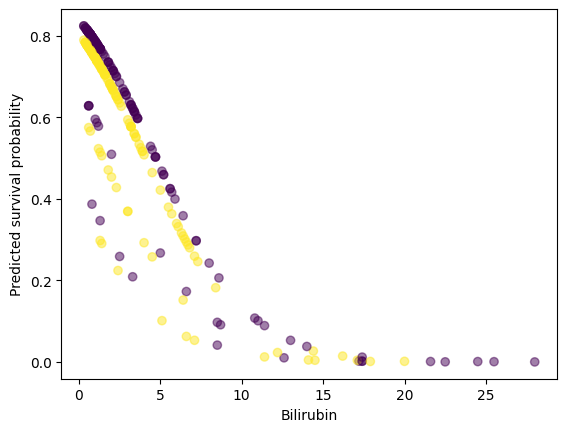

Average difference: -0.018907671240633528


In [16]:
import matplotlib.pyplot as plt

df["pred_prob"] = model.predict_proba(X)[:, 1]

plt.scatter(
    df["Bilirubin"],
    df["pred_prob"],
    c=df["Drug"],
    alpha=0.5
)
plt.xlabel("Bilirubin")
plt.ylabel("Predicted survival probability")
plt.show()

avg_no_drug = df[df["Drug"] == 0]["pred_prob"].mean()
avg_drug = df[df["Drug"] == 1]["pred_prob"].mean()

print("Average difference:", avg_drug - avg_no_drug)

3. The drug does not seem to increase survival at any clear range of bilirubin. The probabilities are generally lower for patients on the drug across most values, so there is no range where it clearly improves survival. On average, patients who take the drug have about a 0.019 lower probability of survival, so the drug slightly decreases predicted survival probability.

In [17]:
from sklearn.metrics import confusion_matrix, accuracy_score

y_pred = model.predict(X)
cm = confusion_matrix(y, y_pred)
print(cm)
acc = accuracy_score(y, y_pred)
print("Accuracy:", acc)

[[ 60  65]
 [ 14 173]]
Accuracy: 0.7467948717948718


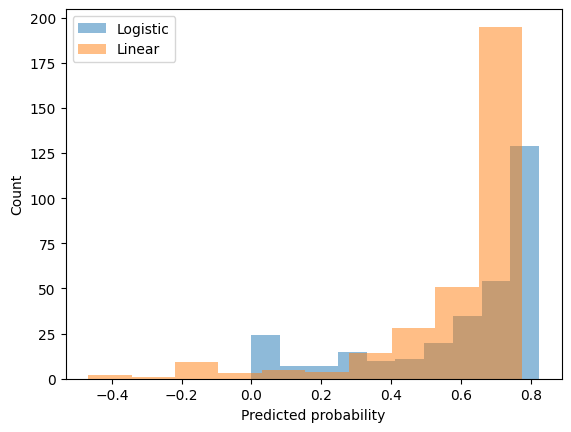

In [18]:
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

lin_model = LinearRegression()
lin_model.fit(X, y)
lin_probs = lin_model.predict(X)
log_probs = model.predict_proba(X)[:, 1]
plt.hist(log_probs, alpha=0.5, label="Logistic")
plt.hist(lin_probs, alpha=0.5, label="Linear")
plt.legend()
plt.xlabel("Predicted probability")
plt.ylabel("Count")
plt.show()

5.The logistic model performs better because its predicted probabilities stay between 0 and 1 and look more realistic. The linear model gives some values below 0, which do not make sense for probabilities. The logistic model also has a smoother and more reasonable distribution, while the linear model is more spread out and less reliable for this type of problem

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

X_stage = df[["Edema", "Bilirubin"]]
y_stage = df["Stage"]
stage_model = LogisticRegression(max_iter=1000)
stage_model.fit(X_stage, y_stage)
stage_preds = stage_model.predict(X_stage)
cm_stage = confusion_matrix(y_stage, stage_preds)
print(cm_stage)
stage_probs = stage_model.predict_proba(X_stage)
print(stage_probs[:5])
print(stage_model.classes_)

[[  0   0  16   0]
 [  0   0  61   6]
 [  0   0 102  18]
 [  0   0  74  35]]
[[3.66170715e-06 2.62122259e-02 1.63752787e-01 8.10031326e-01]
 [7.35327271e-02 2.52874829e-01 4.00994448e-01 2.72597996e-01]
 [2.68744383e-02 1.72053828e-01 3.37699672e-01 4.63372062e-01]
 [2.14080082e-02 1.67391080e-01 3.38389510e-01 4.72811402e-01]
 [2.09867223e-02 2.27849665e-01 4.28140451e-01 3.23023162e-01]]
[1. 2. 3. 4.]


6. The confusion matrix shows that the model is mostly predicting stages 3 and 4, and it is not predicting stages 1 or 2 at all. The first two columns are all zeros, which means none of the observations were classified as stage 1 or stage 2. This suggests the model is not doing a good job separating the lower stages and is mostly grouping everything into the higher stages.The predicted probabilities do include all four stages. Each row has four values, one for each stage, so the model is still assigning some probability to stages 1 and 2 even though it never selects them in the final prediction.
So the hard classification does not predict every class, but the predicted probabilities do include every class.

**Q4.** What are the coefficients of a logistic regression? How do you interpret their values?

1. For your linear model, your predictions are:
$$
\hat{y} = b \cdot x = b_0 + \sum_{k=1}^K b_k x_{k}
$$
What is the derivative of the prediction with respect to the $k$-th feature? For a 1 unit change in your feature, by how much does the prediction change?

2. For the logistic model, your predictions are:
$$
\hat{p}_i = \dfrac{e^{b \cdot x}}{1+e^{b \cdot x}}
$$
What is the derivative of the prediction with respect to the $k$-th feature? As $x$ changes, does your answer change? How is it similar or different from your answer for part 1? Hint: It turns out that
$$
\frac{ \partial }{ \partial L} \dfrac{e^{L}}{1+e^{L}}= \frac{e^{L}}{(1+e^{L})^2} = \frac{e^{L}}{1+e^{L}}\frac{1}{1+e^{L}} = \frac{e^{L}}{1+e^{L}} \left( 1 - \frac{e^{L}}{1+e^{L}} \right),
$$
and use the chain rule( $D_x f(g(x)) = f'(g(x))g'(x)$). For what values of $\hat{p}$ is the coefficient itself (...times 4) roughly a good estimate of how a change in $x_k$ affects the prediction?

3. Alternatively, we can transform the prediction like this:

\begin{alignat*}{2}
\hat{p} &=& \frac{ e^{b \cdot x} }{1+e^{b \cdot x}} \\
\hat{p}(1+e^{b \cdot x}) &=& e^{b \cdot x} \\
\hat{p} &=& (1-\hat{p}) e^{b \cdot x} \\
\log \left( \frac{\hat{p}}{1-\hat{p}} \right) &=& b \cdot x \\
\end{alignat*}

The left-hand side of the above expression is called the **log odds ratio**, and the right-hand side is the latent variable. How does a one unit change in $x_k$ affect the log odds ratio?

The coefficients in a logistic regression are the weights on each feature in the linear part of the model. They tell you how each feature affects the log odds of the outcome. A positive coefficient means the feature increases the chance of the outcome, and a negative coefficient means it decreases the chance. The size tells you how strong that effect is, but it is on the log odds scale, not directly on probability.

1. For the linear model, the prediction is a straight line. The derivative with respect to the k-th feature is just the coefficient bk. This means for a one unit increase in that feature, the prediction increases by exactly bk. It is constant and does not depend on the value of x.

2. For the logistic model, the prediction is not linear. The derivative with respect to the k-th feature is bk⋅p(1−p), where p is the predicted probability. This means the effect of a feature depends on the current value of the prediction. When p changes, the derivative changes too, so the effect is not constant like in the linear model.

The effect is largest when p is around 0.5 because p(1−p) is biggest there. In that case, p(1−p) is about 0.25, so the change is roughly bk/4. That means around p = 0.5, the coefficient (times 0.25, or equivalently divided by 4) gives a rough idea of how much the probability changes.

3. For the log-odds form, a one unit increase in x k increases the log-odds by exactly bk. This is a simple linear relationship, so the coefficient directly tells you the change in log odds.